# Motion-Based Frame Reduction — Exploration Notebook

This notebook lets you:
1. Inspect a CDnet sequence (frames + GT masks)
2. Run a single detector on a sequence and visualise the scores
3. Plot a PR curve for a sequence
4. Compare all detectors side by side

Run from the project root: `jupyter notebook notebooks/exploration.ipynb`

In [2]:
%matplotlib inline

import sys
sys.path.insert(0, '..')  # make src/ importable

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DATASET_ROOT = Path('../data/dataset')

## 1. Load a sequence and inspect its metadata

In [3]:
from src.utils.cdnet_loader import CDnetSequence, load_dataset

CATEGORY = 'baseline'
SEQUENCE = 'highway'

seq = CDnetSequence.load(DATASET_ROOT / CATEGORY / SEQUENCE, category=CATEGORY)
print(seq)
print(f'Temporal ROI: frames {seq.temporal_roi[0]} – {seq.temporal_roi[1]}')
print(f'ROI mask shape: {seq.roi_mask.shape if seq.roi_mask is not None else None}')

CDnetSequence(baseline/highway, temporal_roi=(470, 1700))
Temporal ROI: frames 470 – 1700
ROI mask shape: (240, 320)


## 2. Visualise sample frames and their GT masks

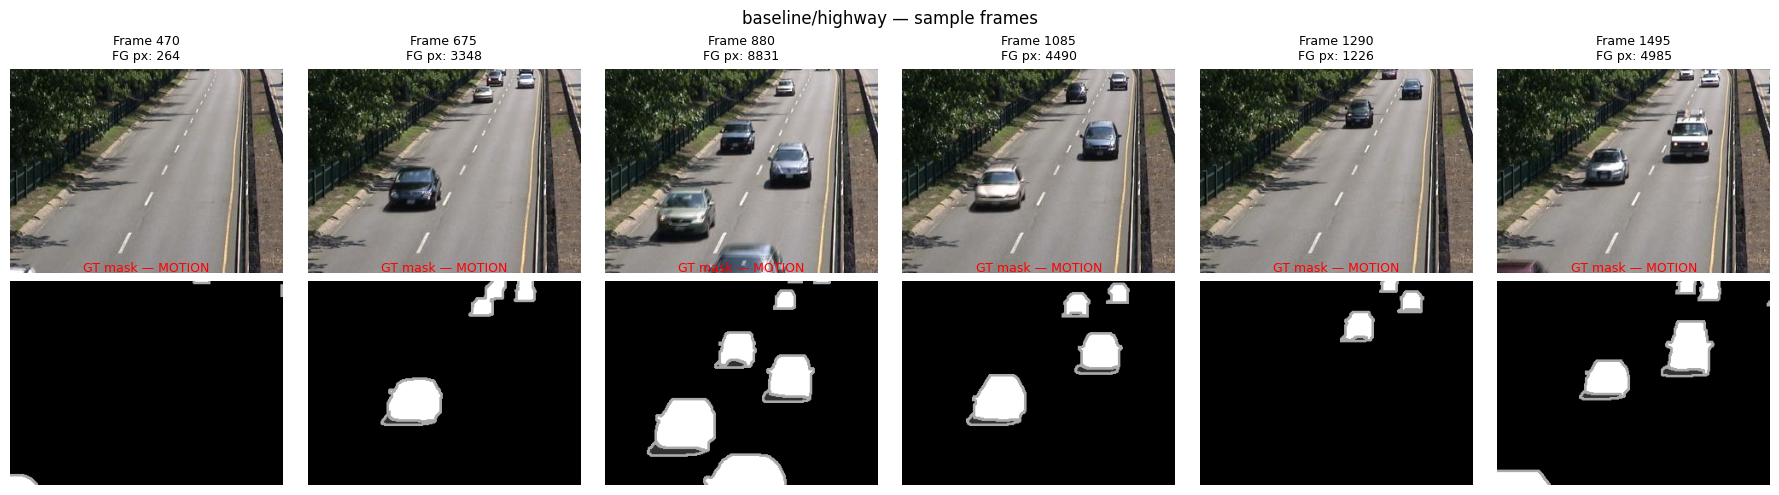

In [4]:
from src.utils.cdnet_loader import derive_frame_label, gt_foreground_count

# Sample 6 frames from the evaluation window
frames_list = list(seq.iter_frames(eval_only=True))
step = max(1, len(frames_list) // 6)
sample_records = frames_list[::step][:6]

fig, axes = plt.subplots(2, len(sample_records), figsize=(18, 5))
for i, rec in enumerate(sample_records):
    frame = rec.load_input()
    gt = rec.load_gt_mask()
    fg_count = gt_foreground_count(gt, seq.roi_mask) if gt is not None else 0
    has_motion = derive_frame_label(gt, seq.roi_mask) if gt is not None else False

    axes[0, i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f'Frame {rec.frame_idx}\nFG px: {fg_count}', fontsize=9)
    axes[0, i].axis('off')

    if gt is not None:
        axes[1, i].imshow(gt, cmap='gray', vmin=0, vmax=255)
        label_str = 'MOTION' if has_motion else 'STATIC'
        axes[1, i].set_title(f'GT mask — {label_str}', fontsize=9,
                              color='red' if has_motion else 'green')
    axes[1, i].axis('off')

fig.suptitle(f'{CATEGORY}/{SEQUENCE} — sample frames', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Run a detector and visualise scores over time

In [6]:
from src.detectors.frame_diff import BlurredFrameDiff, RawFrameDiff
from src.detectors.bg_subtract import MOG2Detector, KNNDetector
from src.detectors.optical_flow import FarnebackDetector

detector = BlurredFrameDiff(pixel_threshold=20, blur_ksize=5)

detector.reset()
frame_indices = []
gt_labels = []
scores = []

for rec in tqdm(seq.iter_frames(eval_only=False), desc='Running detector'):
    frame = rec.load_input()
    score = detector.compute_score(frame)
    if not rec.in_temporal_roi:
        continue
    gt = rec.load_gt_mask()
    if gt is None:
        continue
    label = int(derive_frame_label(gt, seq.roi_mask, min_foreground_pixels=200))
    frame_indices.append(rec.frame_idx)
    gt_labels.append(label)
    scores.append(score)

print(f'Total eval frames: {len(gt_labels)}')
print(f'Motion frames: {sum(gt_labels)} ({100*sum(gt_labels)/len(gt_labels):.1f}%)')
print(f'Score range: [{min(scores):.4f}, {max(scores):.4f}]')

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.fill_between(frame_indices, gt_labels, step='mid', alpha=0.6,
                  color='steelblue', label='GT (1=motion)')
ax1.set_ylabel('GT label')
ax1.set_ylim(-0.1, 1.3)
ax1.legend()
ax1.set_title(f'{CATEGORY}/{SEQUENCE} — GT labels vs detector score ({detector.name})')

ax2.plot(frame_indices, scores, linewidth=0.8, color='darkorange', label='Motion score')
ax2.set_ylabel('Motion score')
ax2.set_xlabel('Frame index')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Threshold sweep and PR curve for this sequence

In [ ]:
from src.eval.metrics import threshold_sweep, best_operating_point
from src.eval.pr_curve import pr_curve_from_sweep, average_precision

sweep = threshold_sweep(gt_labels, scores, n_thresholds=200)
best = best_operating_point(sweep, min_recall=0.95)
recalls, precisions, thresholds = pr_curve_from_sweep(sweep)
ap = average_precision(recalls, precisions)

print(f'Average Precision: {ap:.4f}')
print(f'Best operating point (recall >= 0.95):')
print(f'  threshold   = {best.threshold:.6f}')
print(f'  recall      = {best.recall:.4f}')
print(f'  precision   = {best.precision:.4f}')
print(f'  f1          = {best.f1:.4f}')
print(f'  compression = {best.compression_ratio:.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(recalls, precisions, 'b-', linewidth=1.5, marker='.', markersize=3)
axes[0].axvline(x=best.recall, color='red', linestyle='--', label=f'Best R={best.recall:.3f}')
axes[0].scatter([best.recall], [best.precision], color='red', zorder=5, s=50)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve (AP={ap:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Compression vs Recall
compressions = [m.compression_ratio for m in sorted(sweep, key=lambda m: m.recall)]
axes[1].plot(recalls, compressions, 'g-', linewidth=1.5, marker='.', markersize=3)
axes[1].axvline(x=0.95, color='grey', linestyle='--', label='Target recall=0.95')
axes[1].scatter([best.recall], [best.compression_ratio], color='red', zorder=5, s=50,
                label=f'Best: compression={best.compression_ratio:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Compression ratio')
axes[1].set_title('Compression Ratio vs Recall')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'{CATEGORY}/{SEQUENCE} — {detector.name}', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Compare all detectors on this sequence

In [ ]:
detectors = {
    'raw_diff':     RawFrameDiff(pixel_threshold=25),
    'blurred_diff': BlurredFrameDiff(pixel_threshold=20, blur_ksize=5),
    'mog2':         MOG2Detector(history=500, var_threshold=16.0),
    'knn':          KNNDetector(history=500, dist2_threshold=400.0),
    'flow':         FarnebackDetector(score_mode='mean_norm', max_magnitude=20.0),
}

all_records = list(seq.iter_frames(eval_only=False))
results = {}

for det_name, det in detectors.items():
    det.reset()
    det_scores = []
    det_gt = []
    det_indices = []
    for rec in tqdm(all_records, desc=det_name, leave=False):
        frame = rec.load_input()
        score = det.compute_score(frame)
        if not rec.in_temporal_roi:
            continue
        gt = rec.load_gt_mask()
        if gt is None:
            continue
        label = int(derive_frame_label(gt, seq.roi_mask, 200))
        det_scores.append(score)
        det_gt.append(label)
        det_indices.append(rec.frame_idx)
    sweep = threshold_sweep(det_gt, det_scores, n_thresholds=200)
    best = best_operating_point(sweep, min_recall=0.95)
    r, p, _ = pr_curve_from_sweep(sweep)
    results[det_name] = {'sweep': sweep, 'best': best, 'recalls': r, 'precisions': p}
    print(f'{det_name:20s} recall={best.recall:.3f} precision={best.precision:.3f} '
          f'f1={best.f1:.3f} compression={best.compression_ratio:.3f} '
          f'@ thr={best.threshold:.6f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for det_name, res in results.items():
    ap = average_precision(res['recalls'], res['precisions'])
    axes[0].plot(res['recalls'], res['precisions'], marker='.', markersize=2,
                  linewidth=1.2, label=f"{det_name} (AP={ap:.3f})")

    compressions_sorted = [m.compression_ratio for m in sorted(res['sweep'], key=lambda m: m.recall)]
    recalls_sorted = sorted([m.recall for m in res['sweep']])
    axes[1].plot(recalls_sorted, compressions_sorted, marker='.', markersize=2,
                  linewidth=1.2, label=det_name)

for ax in axes:
    ax.axvline(x=0.95, color='grey', linestyle='--', linewidth=1)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('PR Curves — all detectors')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Compression ratio')
axes[1].set_title('Compression vs Recall — all detectors')

plt.suptitle(f'{CATEGORY}/{SEQUENCE}', fontsize=12)
plt.tight_layout()
plt.show()